# Inner V-angle and torque-ripple physical validation

This report compares a low-ripple/high-ripple pair selected from the independent-angle Sobol 64
population. Magnet usage is matched as closely as the existing DOE permits; torque per magnet area,
ripple, air-gap flux, and Maxwell stress are then compared. Other geometry variables are not identical,
so this is a whole-rotor performance comparison rather than an inner-angle-only causal experiment.

Analysis chain:

$$
\text{Inner angle}\rightarrow B_r(\theta)\text{ harmonics}
\rightarrow \frac{B_rB_t}{\mu_0}\text{ variation}
\rightarrow \text{torque ripple}
$$

,case_label,run,inner_angle_deg,outer_angle_deg,loaded_torque_mean_Nm,loaded_torque_ripple_pct,total_magnet_area_mm2
0,low_ripple,40,78.3712,85.5641,42.3680,6.3417,565.8369
1,high_ripple,45,41.1289,81.0232,40.0505,37.3661,579.8581


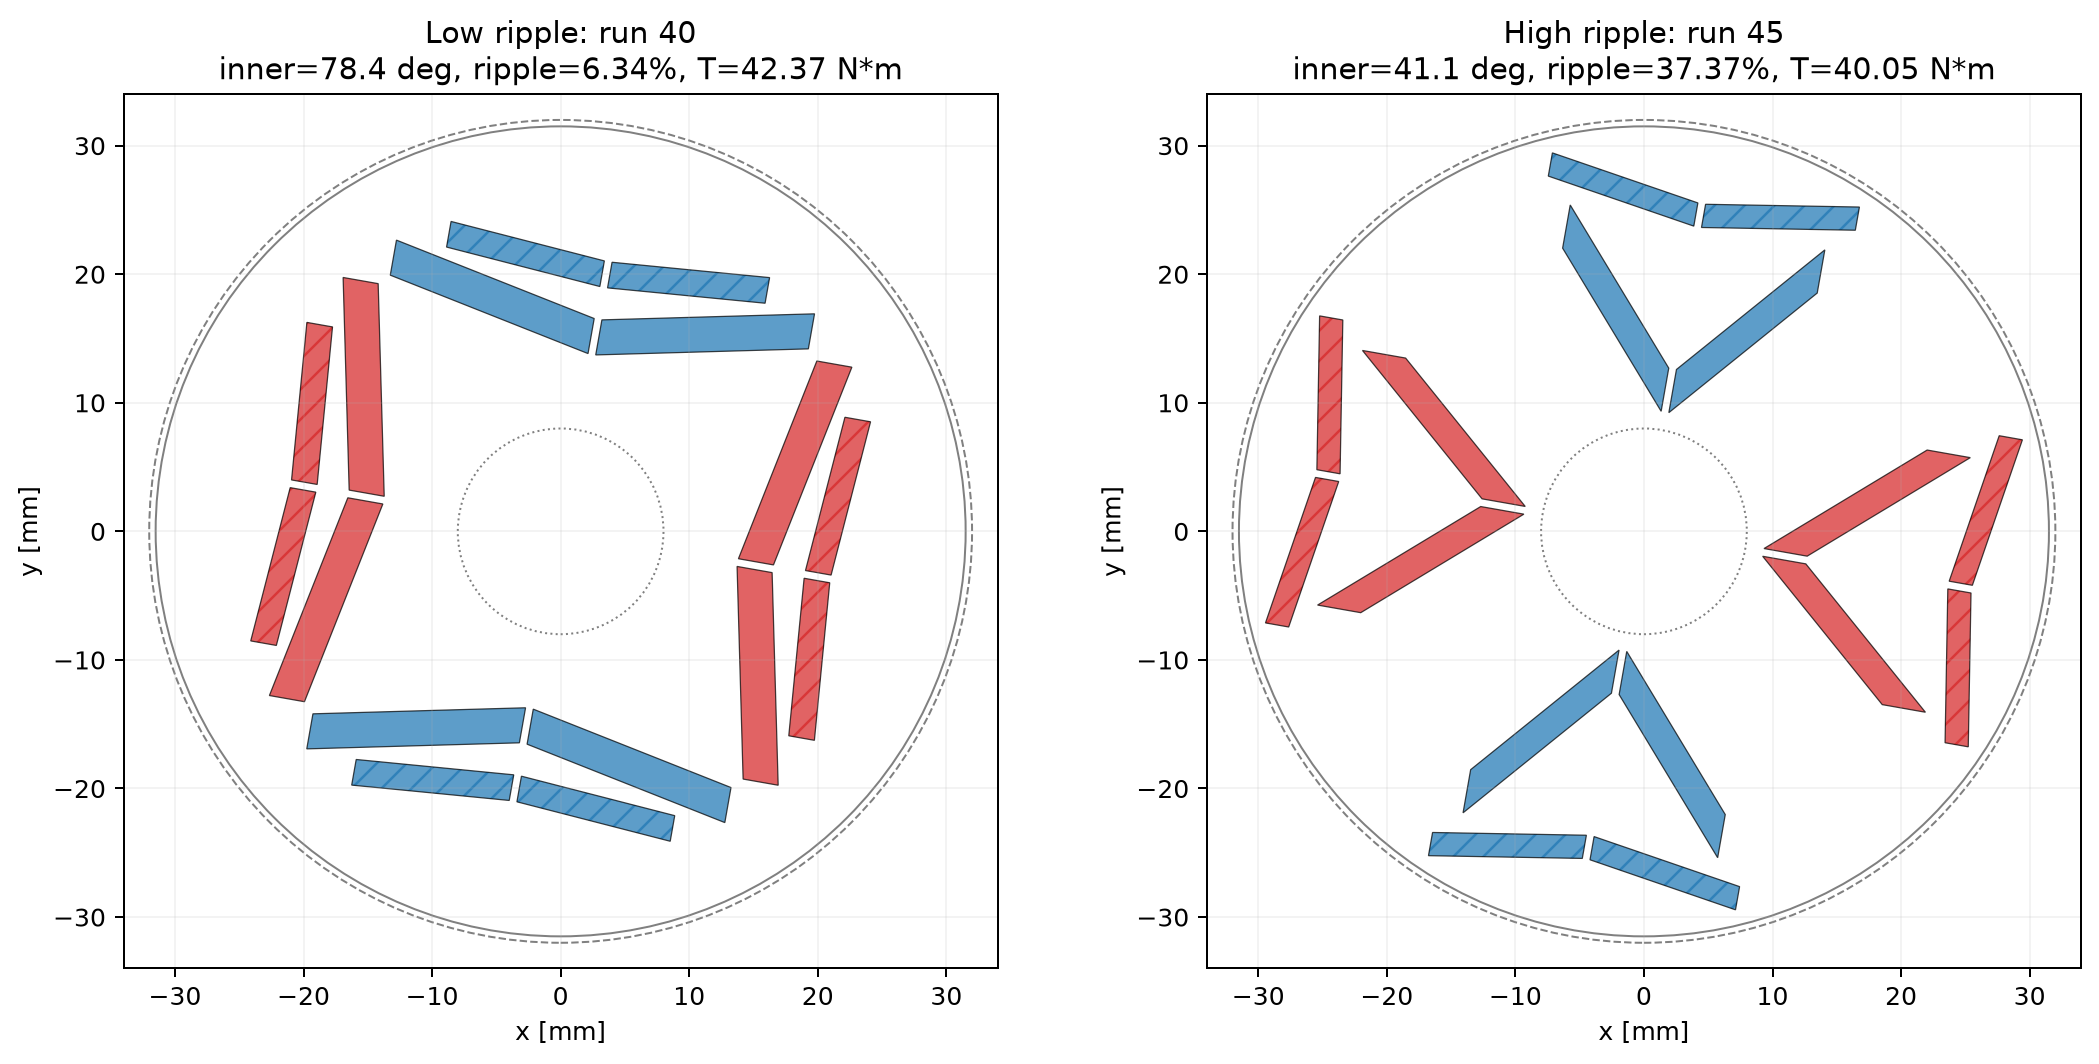

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path.cwd().resolve()
if ROOT.name == 'analysis_results':
    ROOT = ROOT.parent
EXP = ROOT / 'inner_angle_ripple_physics_experiment'
PLAN = pd.read_csv(EXP / 'matched_pair_plan.csv')
display(PLAN[[
    'case_label', 'run', 'inner_angle_deg', 'outer_angle_deg',
    'loaded_torque_mean_Nm', 'loaded_torque_ripple_pct', 'total_magnet_area_mm2'
]].round(4))
display(Image(filename=str(EXP / 'matched_pair_geometry_preview.png')))

## 1. FEMM completion check

In [2]:
case_dirs = {
    row.case_label: EXP / f"{row.case_label}_run_{int(row.run):03d}"
    for _, row in PLAN.iterrows()
}
required = ['torque_sweep.csv', 'airgap_field_and_maxwell_stress.csv', 'FEMM_COMPLETE.json']
status = pd.DataFrame({
    label: {name: (folder / name).exists() for name in required}
    for label, folder in case_dirs.items()
}).T
display(status)
READY = bool(status.to_numpy().all())
if not READY:
    print('FEMM results are not present yet. Run later:')
    print(r'.\.venv\Scripts\python.exe .\run_inner_angle_ripple_physics_experiment.py --run-femm')

,torque_sweep.csv,airgap_field_and_maxwell_stress.csv,FEMM_COMPLETE.json
low_ripple,True,True,True
high_ripple,True,True,True


## 2. Loaded torque waveform and FFT

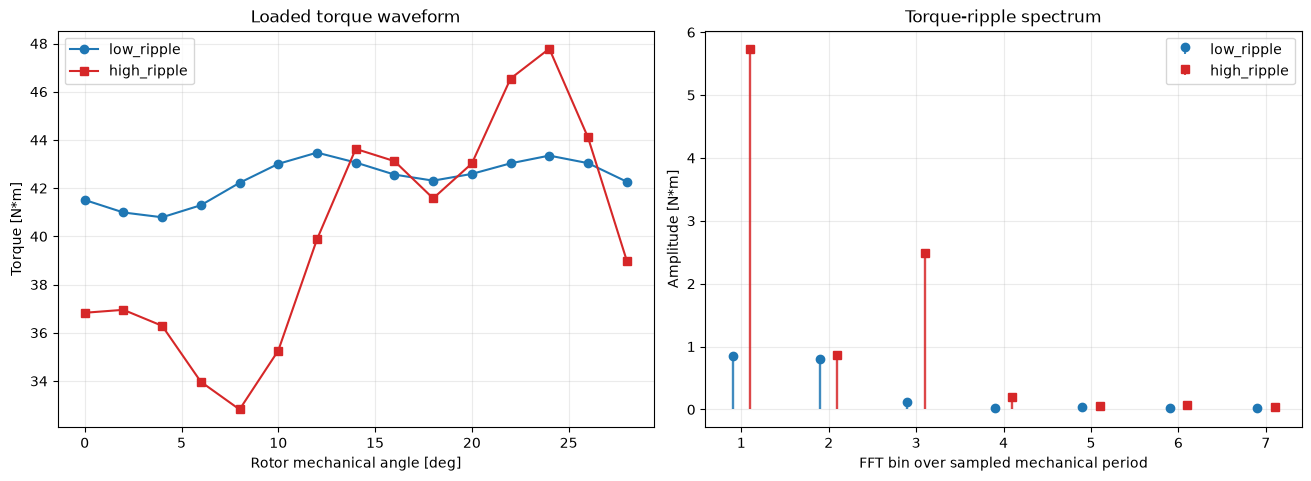

In [3]:
if READY:
    torque = {
        label: pd.read_csv(folder / 'torque_sweep.csv').query("state == 'loaded'")
        for label, folder in case_dirs.items()
    }
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.7), constrained_layout=True)
    styles = {
        'low_ripple': dict(color='#1f77b4', marker='o'),
        'high_ripple': dict(color='#d62728', marker='s'),
    }
    for case_index, (label, data) in enumerate(torque.items()):
        style = styles[label]
        axes[0].plot(data.theta_deg, data.torque_Nm, '-', color=style['color'],
                     marker=style['marker'], label=label)
        centered = data.torque_Nm.to_numpy() - data.torque_Nm.mean()
        amplitude = 2 * np.abs(np.fft.rfft(centered)) / len(centered)
        order = np.arange(len(amplitude))
        markerline, stemlines, baseline = axes[1].stem(
            order[1:] + (-0.10 if case_index == 0 else 0.10), amplitude[1:],
            label=label, basefmt=' '
        )
        plt.setp(markerline, marker=style['marker'], color=style['color'], markersize=6)
        plt.setp(stemlines, color=style['color'], linewidth=1.7, alpha=.85)
    axes[0].set(xlabel='Rotor mechanical angle [deg]', ylabel='Torque [N*m]', title='Loaded torque waveform')
    axes[1].set(xlabel='FFT bin over sampled mechanical period', ylabel='Amplitude [N*m]', title='Torque-ripple spectrum')
    for ax in axes: ax.grid(alpha=.25); ax.legend()

## 3. No-load air-gap radial flux density and spatial FFT

case,high_ripple,low_ripple
spatial_order_per_rev,,
1,0.00007,0.00008
2,0.59929,0.40162
3,0.00009,0.00016
4,0.02956,0.00019
5,0.00007,0.00006
6,0.17574,0.09119
7,0.00009,0.00004
8,0.01890,0.00362
9,0.00006,0.00003


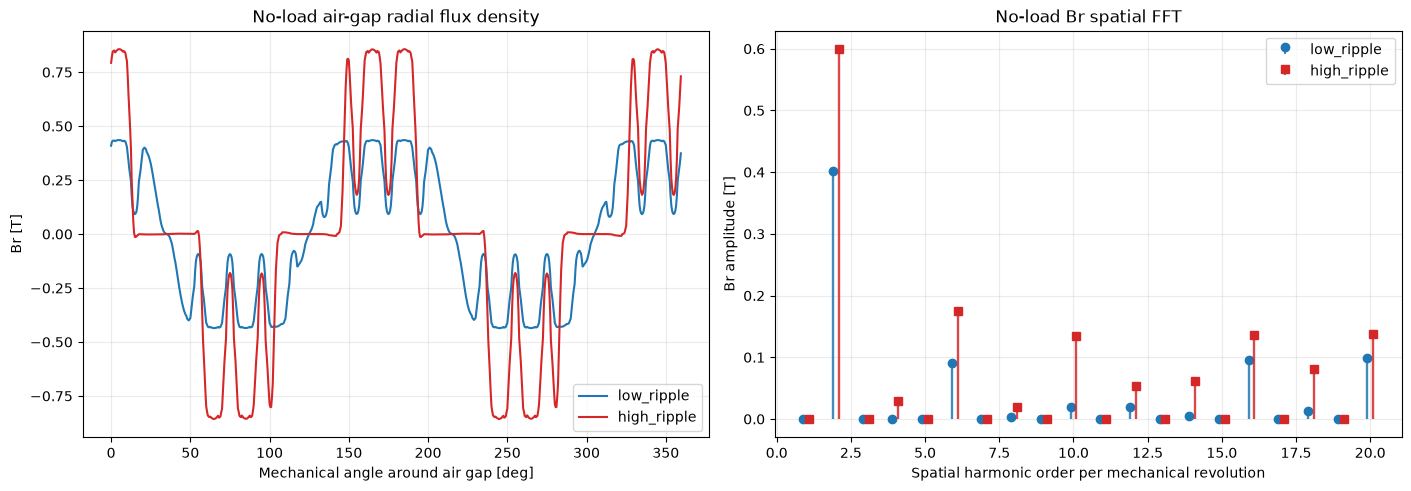

In [4]:
if READY:
    fields = {label: pd.read_csv(folder / 'airgap_field_and_maxwell_stress.csv') for label, folder in case_dirs.items()}
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
    harmonic_rows = []
    for case_index, (label, data) in enumerate(fields.items()):
        style = styles[label]
        no_load = data.query("state == 'no_load'").drop_duplicates('airgap_angle_deg').sort_values('airgap_angle_deg')
        # Remove duplicated 360-degree endpoint for FFT.
        no_load = no_load.loc[no_load.airgap_angle_deg < 360]
        axes[0].plot(no_load.airgap_angle_deg, no_load.Br_T,
                     color=style['color'], label=label)
        signal = no_load.Br_T.to_numpy() - no_load.Br_T.mean()
        amp = 2 * np.abs(np.fft.rfft(signal)) / len(signal)
        orders = np.arange(len(amp))
        markerline, stemlines, baseline = axes[1].stem(
            orders[1:21] + (-0.10 if case_index == 0 else 0.10), amp[1:21],
            label=label, basefmt=' '
        )
        plt.setp(markerline, marker=style['marker'], color=style['color'], markersize=6)
        plt.setp(stemlines, color=style['color'], linewidth=1.7, alpha=.85)
        harmonic_rows.extend({'case': label, 'spatial_order_per_rev': int(k), 'Br_amplitude_T': amp[k]} for k in range(1, min(21, len(amp))))
    axes[0].set(xlabel='Mechanical angle around air gap [deg]', ylabel='Br [T]', title='No-load air-gap radial flux density')
    axes[1].set(xlabel='Spatial harmonic order per mechanical revolution', ylabel='Br amplitude [T]', title='No-load Br spatial FFT')
    for ax in axes: ax.grid(alpha=.25); ax.legend()
    harmonics = pd.DataFrame(harmonic_rows)
    display(harmonics.pivot(index='spatial_order_per_rev', columns='case', values='Br_amplitude_T').round(5))

## 4. Loaded Maxwell shear-stress distribution

The sampled air-gap proxy is

$$
\tau_t(\theta)=\frac{B_r(\theta)B_t(\theta)}{\mu_0}.
$$

Its spatial nonuniformity is compared at identical current and commutation conditions. This is a
local air-gap stress proxy; the FEMM block-integral torque remains the reference total torque.

,spatial_std_kPa,theta_rms_variation_kPa
case,,
low_ripple,389.7596,8.4445
high_ripple,337.6606,9.7605


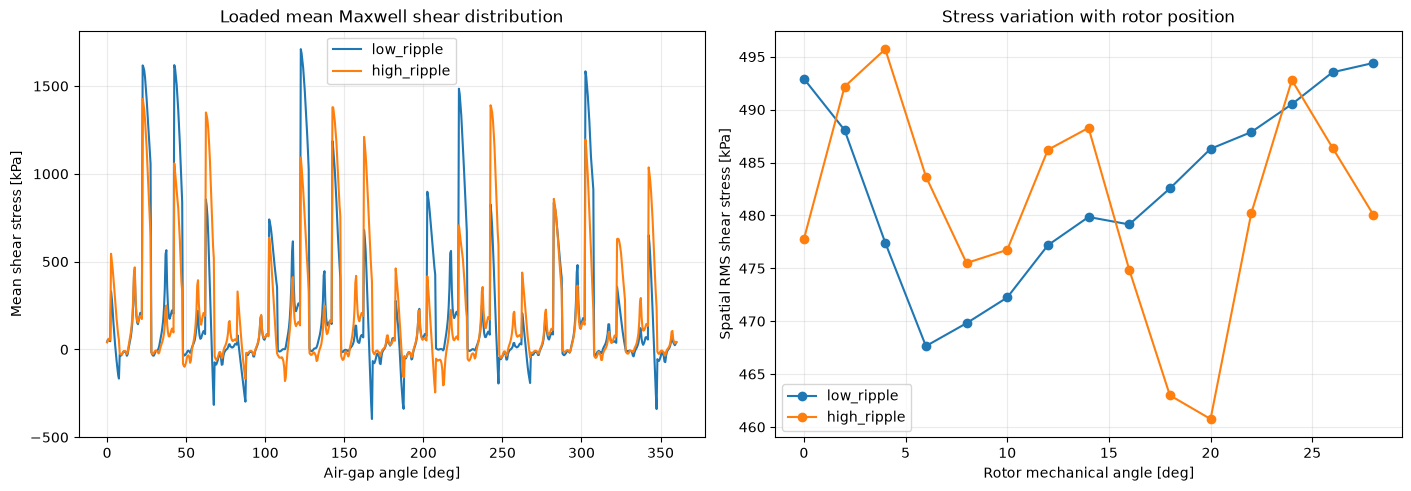

In [5]:
if READY:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
    stress_stats = []
    for label, data in fields.items():
        loaded = data.query("state == 'loaded'")
        mean_by_angle = loaded.groupby('airgap_angle_deg', as_index=False).maxwell_shear_Pa.mean()
        axes[0].plot(mean_by_angle.airgap_angle_deg, mean_by_angle.maxwell_shear_Pa / 1e3, label=label)
        rms_by_theta = loaded.groupby('theta_deg').maxwell_shear_Pa.apply(lambda x: np.sqrt(np.mean(np.square(x))))
        axes[1].plot(rms_by_theta.index, rms_by_theta.values / 1e3, 'o-', label=label)
        stress_stats.append({
            'case': label,
            'spatial_std_kPa': mean_by_angle.maxwell_shear_Pa.std(ddof=0) / 1e3,
            'theta_rms_variation_kPa': rms_by_theta.std(ddof=0) / 1e3,
        })
    axes[0].set(xlabel='Air-gap angle [deg]', ylabel='Mean shear stress [kPa]', title='Loaded mean Maxwell shear distribution')
    axes[1].set(xlabel='Rotor mechanical angle [deg]', ylabel='Spatial RMS shear stress [kPa]', title='Stress variation with rotor position')
    for ax in axes: ax.grid(alpha=.25); ax.legend()
    display(pd.DataFrame(stress_stats).set_index('case').round(4))

## 5. Quantitative evidence chain

In [6]:
if READY:
    evidence_rows = []
    fft_store = {}
    for label in case_dirs:
        plan_row = PLAN.loc[PLAN.case_label == label].iloc[0]
        magnet_area = float(plan_row.total_magnet_area_mm2)
        t = torque[label].sort_values('theta_deg')
        torque_mean = t.torque_Nm.mean()
        torque_pkpk = t.torque_Nm.max() - t.torque_Nm.min()
        torque_ripple = 100 * torque_pkpk / abs(torque_mean)

        no_load = fields[label].query("state == 'no_load'").drop_duplicates('airgap_angle_deg').sort_values('airgap_angle_deg')
        no_load = no_load.loc[no_load.airgap_angle_deg < 360]
        br = no_load.Br_T.to_numpy() - no_load.Br_T.mean()
        br_amp = 2 * np.abs(np.fft.rfft(br)) / len(br)
        fft_store[label] = br_amp

        loaded = fields[label].query("state == 'loaded'")
        shear_spatial_rms = loaded.groupby('theta_deg').maxwell_shear_Pa.apply(
            lambda x: np.sqrt(np.mean(np.square(x)))
        )
        pressure_spatial_rms = loaded.groupby('theta_deg').maxwell_radial_pressure_Pa.apply(
            lambda x: np.sqrt(np.mean(np.square(x)))
        )
        evidence_rows.append({
            'case': label,
            'total_magnet_area_mm2': magnet_area,
            'mean_torque_Nm': torque_mean,
            'torque_per_magnet_area_Nm_per_mm2': torque_mean / magnet_area,
            'torque_pkpk_Nm': torque_pkpk,
            'torque_pkpk_per_magnet_area_Nm_per_mm2': torque_pkpk / magnet_area,
            'torque_ripple_pct': torque_ripple,
            'Br_fundamental_order2_T': br_amp[2],
            'Br_fundamental_per_magnet_area_T_per_mm2': br_amp[2] / magnet_area,
            'Br_total_harmonic_rms_order3plus_T': np.sqrt(np.sum(br_amp[3:21]**2)),
            'Br_harmonic_rms_per_magnet_area_T_per_mm2': np.sqrt(np.sum(br_amp[3:21]**2)) / magnet_area,
            'shear_spatial_RMS_theta_std_kPa': shear_spatial_rms.std(ddof=0) / 1e3,
            'radial_pressure_RMS_theta_std_kPa': pressure_spatial_rms.std(ddof=0) / 1e3,
        })
    evidence = pd.DataFrame(evidence_rows).set_index('case')
    display(evidence.round(5))

    harmonic_comparison = pd.DataFrame({
        'spatial_order': np.arange(1, 21),
        'low_ripple_T': fft_store['low_ripple'][1:21],
        'high_ripple_T': fft_store['high_ripple'][1:21],
    })
    harmonic_comparison['high_minus_low_T'] = harmonic_comparison.high_ripple_T - harmonic_comparison.low_ripple_T
    harmonic_comparison['abs_difference_T'] = harmonic_comparison.high_minus_low_T.abs()
    print('Spatial harmonics with the largest low/high difference:')
    display(harmonic_comparison.nlargest(10, 'abs_difference_T').round(6))

    low, high = evidence.loc['low_ripple'], evidence.loc['high_ripple']
    normalized_comparison = pd.Series({
        'magnet_area_difference_pct_high_vs_low': 100 * (high.total_magnet_area_mm2 / low.total_magnet_area_mm2 - 1),
        'mean_torque_difference_pct_high_vs_low': 100 * (high.mean_torque_Nm / low.mean_torque_Nm - 1),
        'torque_density_difference_pct_high_vs_low': 100 * (high.torque_per_magnet_area_Nm_per_mm2 / low.torque_per_magnet_area_Nm_per_mm2 - 1),
        'ripple_difference_pctpoint_high_minus_low': high.torque_ripple_pct - low.torque_ripple_pct,
        'Br_fundamental_per_area_difference_pct': 100 * (high.Br_fundamental_per_magnet_area_T_per_mm2 / low.Br_fundamental_per_magnet_area_T_per_mm2 - 1),
        'Br_harmonic_RMS_per_area_difference_pct': 100 * (high.Br_harmonic_rms_per_magnet_area_T_per_mm2 / low.Br_harmonic_rms_per_magnet_area_T_per_mm2 - 1),
    })
    print('Magnet-usage-normalized comparison:')
    display(normalized_comparison.to_frame('value').round(4))
    checks = pd.Series({
        'rerun_preserves_high_ripple_label': high.torque_ripple_pct > low.torque_ripple_pct,
        'high_case_has_larger_Br_harmonic_RMS': high.Br_total_harmonic_rms_order3plus_T > low.Br_total_harmonic_rms_order3plus_T,
        'high_case_has_larger_shear_variation': high.shear_spatial_RMS_theta_std_kPa > low.shear_spatial_RMS_theta_std_kPa,
        'high_case_has_larger_radial_pressure_variation': high.radial_pressure_RMS_theta_std_kPa > low.radial_pressure_RMS_theta_std_kPa,
    })
    display(checks.to_frame('supported'))
    support_count = int(checks.sum())
    print(f'Evidence-chain checks supported: {support_count}/{len(checks)}')
    if support_count == len(checks):
        print('Conclusion: at nearly matched magnet usage, the rerun consistently supports an air-gap-field / Maxwell-stress explanation of the torque-density and ripple differences.')
    elif checks.iloc[0] and checks.iloc[2]:
        print('Conclusion: torque and tangential-stress variation support the mechanism, but the Br harmonic or radial-pressure evidence is mixed. Do not claim a single harmonic as the sole cause.')
    else:
        print('Conclusion: the current matched-pair rerun does not yet establish a consistent electromagnetic explanation; refine the comparison or sampling.')

,total_magnet_area_mm2,mean_torque_Nm,torque_per_magnet_area_Nm_per_mm2,torque_pkpk_Nm,torque_pkpk_per_magnet_area_Nm_per_mm2,torque_ripple_pct,Br_fundamental_order2_T,Br_fundamental_per_magnet_area_T_per_mm2,Br_total_harmonic_rms_order3plus_T,Br_harmonic_rms_per_magnet_area_T_per_mm2,shear_spatial_RMS_theta_std_kPa,radial_pressure_RMS_theta_std_kPa
case,,,,,,,,,,,,
low_ripple,565.83691,42.36627,0.07487,2.68286,0.00474,6.33253,0.40162,0.00071,0.16820,0.00030,8.44452,5.89033
high_ripple,579.85812,40.05138,0.06907,14.96540,0.02581,37.36552,0.59929,0.00103,0.31735,0.00055,9.76055,9.65366


Spatial harmonics with the largest low/high difference:


,spatial_order,low_ripple_T,high_ripple_T,high_minus_low_T,abs_difference_T
1,2,0.401618,0.599289,0.197671,0.197671
9,10,0.020013,0.133783,0.113770,0.113770
5,6,0.091191,0.175738,0.084547,0.084547
17,18,0.012960,0.080788,0.067828,0.067828
13,14,0.005440,0.061551,0.056110,0.056110
19,20,0.098669,0.138381,0.039712,0.039712
15,16,0.096041,0.135675,0.039634,0.039634
11,12,0.020104,0.053155,0.033050,0.033050
3,4,0.000191,0.029559,0.029368,0.029368
7,8,0.003621,0.018905,0.015284,0.015284


Magnet-usage-normalized comparison:


,value
magnet_area_difference_pct_high_vs_low,2.4780
mean_torque_difference_pct_high_vs_low,-5.4640
torque_density_difference_pct_high_vs_low,-7.7499
ripple_difference_pctpoint_high_minus_low,31.0330
Br_fundamental_per_area_difference_pct,45.6106
Br_harmonic_RMS_per_area_difference_pct,84.1136


,supported
rerun_preserves_high_ripple_label,True
high_case_has_larger_Br_harmonic_RMS,True
high_case_has_larger_shear_variation,True
high_case_has_larger_radial_pressure_variation,True


Evidence-chain checks supported: 4/4
Conclusion: at nearly matched magnet usage, the rerun consistently supports an air-gap-field / Maxwell-stress explanation of the torque-density and ripple differences.


## 6. Interpretation checklist

- Do the two cases retain a large ripple difference after rerun?
- Which $B_r$ spatial harmonics differ most strongly?
- Do those changes coincide with torque-spectrum components rather than only increasing peak $B_r$?
- Does the high-ripple case show stronger spatial/rotor-position variation in $B_rB_t/\mu_0$?
- Are local bridge/tip flux-density concentrations visible in the saved FEMM B-magnitude images?

A causal statement should be made only when the geometry change, air-gap harmonic change, Maxwell
stress variation, and torque-ripple change form a consistent chain.

## Standardized Research Conclusion
<!-- STANDARDIZED_RESEARCH_CONCLUSION -->

**Research Question.** 거의 같은 자석량의 저·고리플 차이를 공극 고조파와 Maxwell stress로 설명할 수 있는가?

**Answer.** 전체 로터 비교에서는 설명 사슬이 일관됐다. 고리플 형상은 토크밀도가 7.75% 낮고 리플률은 6.33%에서 37.37%로 증가했으며, 면적당 비기본파 RMS는 84.1% 컸다. 고조파·전단응력·반경압력 검사 4개가 모두 같은 방향이었다.

**Limitation.** 면적 차이는 2.48%이고 다른 변수들도 같지 않아 inner angle 하나의 순수 인과효과는 아니다.

**Next Step.** 나머지 변수와 면적을 고정한 inner-angle 통제실험을 수행한다.